In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import pymysql
import warnings
import matplotlib.pyplot as plt
from matplotlib import font_manager
from datetime import datetime
from scipy.stats import chi2_contingency, chisquare, ttest_ind, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✅ 环境配置完成）")

✅ 环境配置完成）


In [2]:
mysql_user = "root"
mysql_password = "123456"
mysql_host = "localhost"
mysql_port = 3306

engine = create_engine(f"mysql+pymysql://{mysql_user}:{mysql_password}@{mysql_host}:{mysql_port}/?charset=utf8")

with engine.connect() as conn:
    conn.execute(text("CREATE DATABASE IF NOT EXISTS product_analysis CHARACTER SET utf8mb4;"))
    conn.commit()

engine = create_engine(f"mysql+pymysql://{mysql_user}:{mysql_password}@{mysql_host}:{mysql_port}/product_analysis?charset=utf8")
print("✅ 数据库 product_analysis 已就绪")

✅ 数据库 product_analysis 已就绪


In [3]:
file_path = "UserBehavior.csv"

print("正在分块读取数据，寻找数据量充足的候选商品...")
chunk_iter = pd.read_csv(
    file_path, encoding="utf-8", on_bad_lines="skip",
    names=["user_id", "product_id", "category_id", "behavior_type", "timestamp"],
    chunksize=100000
)

product_stats = {}
total_rows = 0
for chunk in chunk_iter:
    total_rows += len(chunk)
    buy_counts = chunk[chunk['behavior_type'] == 'buy']['product_id'].value_counts()
    pv_counts = chunk[chunk['behavior_type'] == 'pv']['product_id'].value_counts()
    for pid in buy_counts.index:
        if pid not in product_stats:
            product_stats[pid] = {'buy': 0, 'pv': 0, 'category': None}
        product_stats[pid]['buy'] += buy_counts[pid]
    for pid in pv_counts.index:
        if pid not in product_stats:
            product_stats[pid] = {'buy': 0, 'pv': 0, 'category': None}
        product_stats[pid]['pv'] += pv_counts[pid]
    for _, row in chunk[chunk['product_id'].isin(buy_counts.index)][['product_id', 'category_id']].drop_duplicates().iterrows():
        if product_stats[row['product_id']]['category'] is None:
            product_stats[row['product_id']]['category'] = row['category_id']
    if total_rows >= 5000000:
        break

candidates = []
for pid, stats in product_stats.items():
    if stats['buy'] >= 30 and stats['pv'] >= 500:
        candidates.append((pid, stats['buy'], stats['pv'], stats['category']))
candidates.sort(key=lambda x: x[2], reverse=True)
print(f"候选商品数: {len(candidates)}")
for c in candidates[:5]:
    print(f"  product_id={c[0]}, buy={c[1]}, pv={c[2]}, category_id={c[3]}")

正在分块读取数据，寻找数据量充足的候选商品...
候选商品数: 1
  product_id=3031354, buy=41, pv=948, category_id=2735466


In [4]:
target_product = str(candidates[0][0])
target_category = str(candidates[0][3])
print(f"🎯 选定目标商品: product_id = {target_product}, category_id = {target_category}")

🎯 选定目标商品: product_id = 3031354, category_id = 2735466


In [5]:
create_table_query = f"""
CREATE TABLE IF NOT EXISTS product_{target_product}_cleaned (
    user_id VARCHAR(50),
    behavior_type VARCHAR(20),
    behavior_time DATETIME,
    date DATE,
    hour INT,
    is_buy INT,
    is_intent INT,
    daily_pv_count INT,
    cumulative_actions INT
);
"""
with engine.connect() as conn:
    conn.execute(text(create_table_query))
    conn.commit()

print("正在分块处理全量数据，只保留目标商品...")
chunk_iter = pd.read_csv(
    file_path, encoding="utf-8", on_bad_lines="skip",
    names=["user_id", "product_id", "category_id", "behavior_type", "timestamp"],
    chunksize=100000
)

total_filtered = 0
for i, chunk in enumerate(chunk_iter):
    chunk = chunk[chunk['product_id'] == int(target_product)].copy()
    if len(chunk) == 0:
        continue
    chunk["behavior_time"] = pd.to_datetime(chunk["timestamp"], unit="s")
    chunk = chunk[(chunk["behavior_time"] >= "2017-11-25") & (chunk["behavior_time"] <= "2017-12-03 23:59:59")]
    if len(chunk) == 0:
        continue
    chunk["date"] = chunk["behavior_time"].dt.date
    chunk["hour"] = chunk["behavior_time"].dt.hour
    chunk = chunk.drop_duplicates(subset=["user_id", "behavior_type", "timestamp"], keep="first")
    chunk = chunk.sort_values(["user_id", "behavior_time"])
    chunk["is_buy"] = (chunk["behavior_type"] == "buy").astype(int)
    chunk["is_intent"] = (chunk["behavior_type"].isin(["cart", "fav"])).astype(int)
    chunk["daily_pv_count"] = chunk.groupby(["user_id", "date"])["behavior_type"].transform(lambda x: (x == "pv").sum())
    chunk["cumulative_actions"] = chunk.groupby("user_id").cumcount() + 1
    chunk[["user_id", "behavior_type", "behavior_time", "date", "hour", 
           "is_buy", "is_intent", "daily_pv_count", "cumulative_actions"]].to_sql(
        f"product_{target_product}_cleaned", con=engine, if_exists="append", index=False
    )
    total_filtered += len(chunk)
    if (i+1) % 50 == 0:
        print(f"  已处理 {i+1} 个分块，累计过滤 {total_filtered:,} 行")

print(f"✅ 全量处理完成，目标商品共 {total_filtered:,} 行数据已入库")

正在分块处理全量数据，只保留目标商品...
  已处理 50 个分块，累计过滤 1,085 行
  已处理 100 个分块，累计过滤 2,111 行
  已处理 150 个分块，累计过滤 3,034 行
  已处理 200 个分块，累计过滤 4,036 行
  已处理 250 个分块，累计过滤 5,052 行
  已处理 300 个分块，累计过滤 6,086 行
  已处理 350 个分块，累计过滤 6,955 行
  已处理 400 个分块，累计过滤 8,016 行
  已处理 450 个分块，累计过滤 9,086 行
  已处理 500 个分块，累计过滤 10,130 行
  已处理 550 个分块，累计过滤 11,080 行
  已处理 600 个分块，累计过滤 12,117 行
  已处理 650 个分块，累计过滤 13,207 行
  已处理 700 个分块，累计过滤 14,259 行
  已处理 750 个分块，累计过滤 15,151 行
  已处理 800 个分块，累计过滤 16,168 行
  已处理 850 个分块，累计过滤 17,205 行
  已处理 900 个分块，累计过滤 18,271 行
  已处理 950 个分块，累计过滤 19,141 行
  已处理 1000 个分块，累计过滤 20,122 行
✅ 全量处理完成，目标商品共 20,155 行数据已入库


In [6]:
validation_query = f"""
SELECT 
    COUNT(*) as total_rows,
    COUNT(DISTINCT user_id) as unique_users,
    MIN(date) as start_date,
    MAX(date) as end_date,
    SUM(is_buy) as total_buy,
    ROUND(SUM(is_buy) * 100.0 / COUNT(DISTINCT user_id), 2) as conversion_rate
FROM product_{target_product}_cleaned;
"""
result = pd.read_sql(validation_query, con=engine)
print("📊 目标商品清洗后数据概览：")
print(result.to_string(index=False))

📊 目标商品清洗后数据概览：
 total_rows  unique_users start_date   end_date  total_buy  conversion_rate
     241860         13306 2017-11-25 2017-12-03    11304.0            84.95


In [7]:
daily_query = f"""
DROP TABLE IF EXISTS product_{target_product}_daily;
CREATE TABLE product_{target_product}_daily AS
SELECT 
    user_id,
    date,
    SUM(CASE WHEN behavior_type='pv' THEN 1 ELSE 0 END) as pv_count,
    SUM(CASE WHEN behavior_type='cart' THEN 1 ELSE 0 END) as cart_count,
    SUM(CASE WHEN behavior_type='fav' THEN 1 ELSE 0 END) as fav_count,
    MAX(is_buy) as is_buy,
    MAX(is_intent) as has_intent,
    MAX(daily_pv_count) as daily_pv_total
FROM product_{target_product}_cleaned
GROUP BY user_id, date;
"""
with engine.connect() as conn:
    for stmt in daily_query.strip().split(';'):
        if stmt.strip():
            conn.execute(text(stmt))
    conn.commit()
print("✅ 日报表构建完成")

✅ 日报表构建完成


In [8]:
print("正在验证数据完整性（含过滤统计）...")

total_in_file = 0
filtered_by_time = 0
duplicated_rows = 0
seen_records = set()

chunk_iter = pd.read_csv(
    file_path, encoding="utf-8", on_bad_lines="skip",
    names=["user_id", "product_id", "category_id", "behavior_type", "timestamp"],
    chunksize=500000
)

for chunk in chunk_iter:
    chunk = chunk[chunk['product_id'] == int(target_product)].copy()
    if len(chunk) == 0:
        continue
    
    total_in_file += len(chunk)
    chunk["behavior_time"] = pd.to_datetime(chunk["timestamp"], unit="s")
    
    # 时间范围过滤统计
    in_time_range = (chunk["behavior_time"] >= "2017-11-25") & (chunk["behavior_time"] <= "2017-12-03 23:59:59")
    filtered_by_time += len(chunk) - in_time_range.sum()
    
    # 去重统计（同一用户同一秒同行为）
    for _, row in chunk[in_time_range].iterrows():
        key = (row['user_id'], row['behavior_type'], row['timestamp'])
        if key in seen_records:
            duplicated_rows += 1
        else:
            seen_records.add(key)

# 计算理论应入库记录数
theoretical_keep = total_in_file - filtered_by_time - duplicated_rows

print("\n" + "="*50)
print("📊 完整性验证报告")
print("="*50)
print(f"文件中原始记录数: {total_in_file}")
print(f"  - 因时间超出范围被过滤: {filtered_by_time} 行")
print(f"  - 因重复行为被去重: {duplicated_rows} 行")
print(f"  - 理论应入库记录数: {theoretical_keep}")
print(f"  - 实际入库记录数: {total_filtered}")
print("="*50)

if theoretical_keep == total_filtered:
    print("✅ 数据提取完整，所有有效记录均已入库，无遗漏")
else:
    print(f"⚠️ 存在无法解释的差异: {theoretical_keep - total_filtered} 行，请检查分块写入逻辑")

正在验证数据完整性（含过滤统计）...

📊 完整性验证报告
文件中原始记录数: 20406
  - 因时间超出范围被过滤: 251 行
  - 因重复行为被去重: 0 行
  - 理论应入库记录数: 20155
  - 实际入库记录数: 20155
✅ 数据提取完整，所有有效记录均已入库，无遗漏


In [9]:
print("="*50)
print(f"🎯 商品 {target_product} 数据清洗完成")
print("="*50)
print(f"清洗后数据量：{total_filtered:,} 行")
print(f"涉及用户数：{result['unique_users'].values[0]:,} 人")
print(f"时间跨度：{result['start_date'].values[0]} ~ {result['end_date'].values[0]}")
print(f"整体转化率：{result['conversion_rate'].values[0]}%")
print("\n✅ 数据已保存在 MySQL 中，可直接用于后续分析")

🎯 商品 3031354 数据清洗完成
清洗后数据量：20,155 行
涉及用户数：13,306 人
时间跨度：2017-11-25 ~ 2017-12-03
整体转化率：84.95%

✅ 数据已保存在 MySQL 中，可直接用于后续分析


📊 数据探索性分析 (EDA)


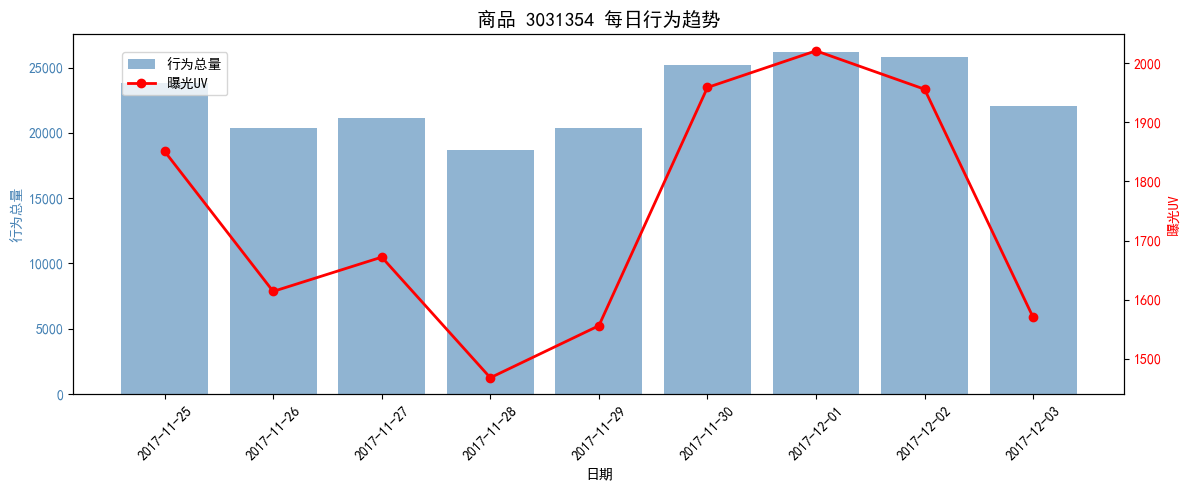


📈 每日曝光UV统计：
count       9
mean     1741
std       207
min      1468
25%      1570
50%      1672
75%      1956
max      2021
Name: exposure_uv, dtype: int64
中位数: 1672


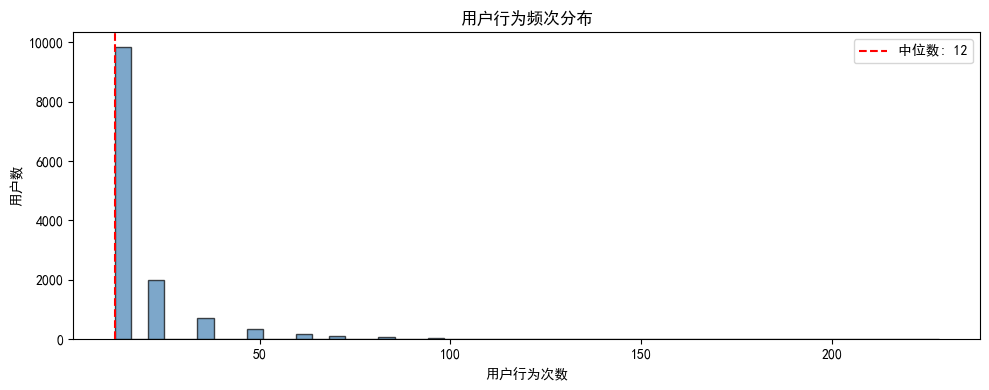


📊 转化漏斗（行为次数）：
  pv: 203,700
  cart: 20,760
  fav: 6,096
  buy: 11,304

📊 转化漏斗（独立用户数）：
  pv: 12,114 (100.0%)
  cart: 1,659 (13.7%)
  fav: 502 (4.1%)
  buy: 869 (7.2%)


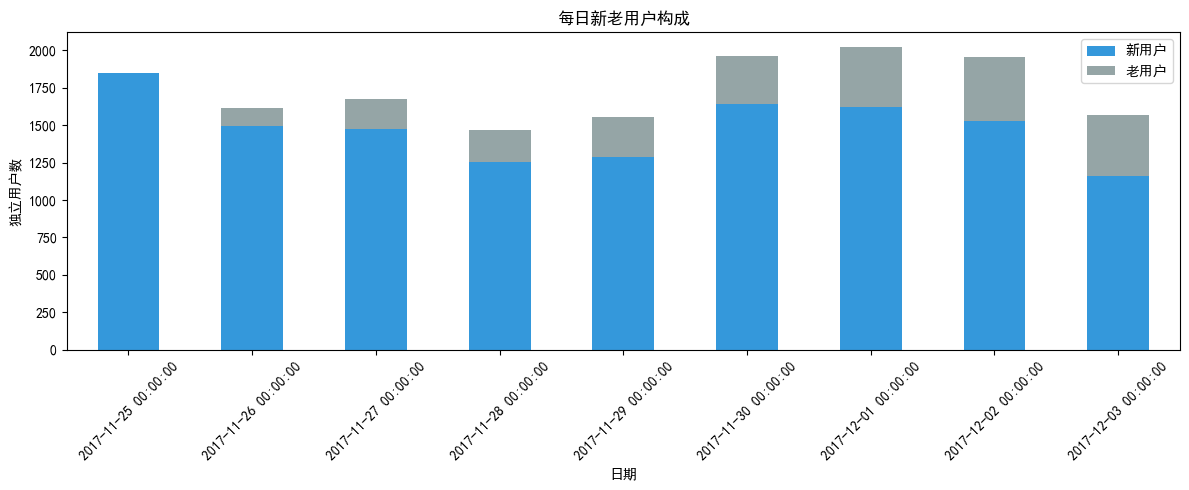

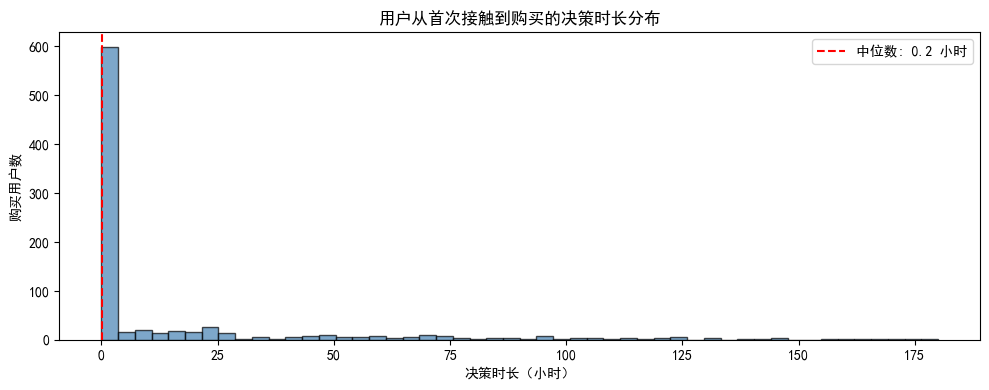


✅ EDA 完成，图表已保存至 outputs/ 文件夹


In [10]:
import os
os.makedirs('outputs', exist_ok=True)

# 读取数据
df = pd.read_sql(f"SELECT * FROM product_{target_product}_cleaned", con=engine)
df['date'] = pd.to_datetime(df['date'])
df['weekday'] = df['date'].dt.weekday + 1  # 1=周一, 7=周日

daily_df = pd.read_sql(f"SELECT * FROM product_{target_product}_daily", con=engine)
daily_df['date'] = pd.to_datetime(daily_df['date'])

print("="*50)
print("📊 数据探索性分析 (EDA)")
print("="*50)

# ==================== 1. 每日行为趋势（曝光UV折线图 + 行为总量柱状图） ====================
daily_agg = daily_df.groupby('date').agg(
    exposure_uv=('user_id', 'nunique'),
    total_actions=('pv_count', 'sum'),
    buy_count=('is_buy', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.bar(daily_agg['date'].astype(str), daily_agg['total_actions'], alpha=0.6, label='行为总量', color='steelblue')
ax1.set_xlabel('日期')
ax1.set_ylabel('行为总量', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticklabels(daily_agg['date'].astype(str), rotation=45)

ax2 = ax1.twinx()
ax2.plot(daily_agg['date'].astype(str), daily_agg['exposure_uv'], color='red', marker='o', linewidth=2, label='曝光UV')
ax2.set_ylabel('曝光UV', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'商品 {target_product} 每日行为趋势', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('outputs/daily_trend.png', dpi=150)
plt.show()

# ==================== 2. 曝光UV统计 ====================
print("\n📈 每日曝光UV统计：")
print(daily_agg['exposure_uv'].describe().round(0).astype(int))
median_uv = int(daily_agg['exposure_uv'].median())
print(f"中位数: {median_uv}")

# ==================== 3. 用户行为频次分布 ====================
user_actions = df.groupby('user_id').size().reset_index(name='action_count')
plt.figure(figsize=(10,4))
plt.hist(user_actions['action_count'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('用户行为次数')
plt.ylabel('用户数')
plt.title('用户行为频次分布')
plt.axvline(user_actions['action_count'].median(), color='red', linestyle='--', 
            label=f"中位数: {int(user_actions['action_count'].median())}")
plt.legend()
plt.tight_layout()
plt.savefig('outputs/user_action_dist.png', dpi=150)
plt.show()

# ==================== 4. 转化漏斗（行为次数） ====================
funnel = df['behavior_type'].value_counts().reindex(['pv', 'cart', 'fav', 'buy']).fillna(0)
print("\n📊 转化漏斗（行为次数）：")
for beh in ['pv', 'cart', 'fav', 'buy']:
    print(f"  {beh}: {int(funnel[beh]):,}")

# ==================== 5. 转化漏斗（独立用户数） ====================
funnel_users = df.groupby('behavior_type')['user_id'].nunique().reindex(['pv', 'cart', 'fav', 'buy']).fillna(0)
pv_users = int(funnel_users['pv'])
print("\n📊 转化漏斗（独立用户数）：")
for beh in ['pv', 'cart', 'fav', 'buy']:
    users = int(funnel_users[beh])
    rate = users / pv_users * 100 if pv_users > 0 else 0
    print(f"  {beh}: {users:,} ({rate:.1f}%)")

# ==================== 6. 新老用户每日构成 ====================
user_first = daily_df.groupby('user_id')['date'].min().reset_index()
user_first.columns = ['user_id', 'first_date']
daily_df = daily_df.merge(user_first, on='user_id')
daily_df['user_type'] = daily_df.apply(lambda r: '新用户' if r['date'] == r['first_date'] else '老用户', axis=1)

daily_type = daily_df.groupby(['date', 'user_type'])['user_id'].nunique().reset_index()
pivot_type = daily_type.pivot(index='date', columns='user_type', values='user_id').fillna(0)
pivot_type.plot(kind='bar', stacked=True, figsize=(12,5), color=['#3498db', '#95a5a6'])
plt.title('每日新老用户构成')
plt.xlabel('日期')
plt.ylabel('独立用户数')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('outputs/new_vs_old_users.png', dpi=150)
plt.show()

# ==================== 7. 用户行为间隔分析（决策时长） ====================
buy_users = df[df['behavior_type'] == 'buy']['user_id'].unique()
buy_user_first = df[df['user_id'].isin(buy_users)].groupby('user_id')['behavior_time'].min().reset_index()
buy_user_first.columns = ['user_id', 'first_time']
buy_user_buy = df[df['behavior_type'] == 'buy'].groupby('user_id')['behavior_time'].min().reset_index()
buy_user_buy.columns = ['user_id', 'buy_time']
decision_time = buy_user_first.merge(buy_user_buy, on='user_id')
decision_time['decision_hours'] = (decision_time['buy_time'] - decision_time['first_time']).dt.total_seconds() / 3600

plt.figure(figsize=(10,4))
plt.hist(decision_time['decision_hours'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('决策时长（小时）')
plt.ylabel('购买用户数')
plt.title('用户从首次接触到购买的决策时长分布')
plt.axvline(decision_time['decision_hours'].median(), color='red', linestyle='--',
            label=f"中位数: {decision_time['decision_hours'].median():.1f} 小时")
plt.legend()
plt.tight_layout()
plt.savefig('outputs/decision_time.png', dpi=150)
plt.show()

print("\n✅ EDA 完成，图表已保存至 outputs/ 文件夹")

In [11]:
daily_agg['day_type'] = daily_agg['date'].apply(lambda d: '周末' if d.weekday() >= 5 else '工作日')
daily_agg['exposure_level'] = np.where(daily_agg['exposure_uv'] >= median_uv, '高曝光', '低曝光')
daily_agg['period'] = daily_agg['date'].apply(lambda d: '预热期' if d >= pd.to_datetime('2017-12-01') else '非预热期')

def calc_conv_stats(df, group_col):
    stats = df.groupby(group_col).agg(
        total_uv=('exposure_uv', 'sum'),
        total_buy=('buy_count', 'sum')
    ).reset_index()
    stats['conversion'] = (stats['total_buy'] / stats['total_uv'] * 100).round(2)
    return stats

day_type_stats = calc_conv_stats(daily_agg, 'day_type')
exposure_stats = calc_conv_stats(daily_agg, 'exposure_level')
period_stats = calc_conv_stats(daily_agg, 'period')

print("📊 工作日 vs 周末转化率对比：")
print(day_type_stats[['day_type', 'conversion']])

print("\n📊 高曝光 vs 低曝光转化率对比：")
print(exposure_stats[['exposure_level', 'conversion']])

print("\n📊 预热期 vs 非预热期转化率对比：")
print(period_stats[['period', 'conversion']])

# 比例检验
def prop_test(df, group_col, group_a, group_b):
    sub = df[df[group_col].isin([group_a, group_b])]
    counts = sub.groupby(group_col).agg({'total_buy': 'sum', 'total_uv': 'sum'})
    if len(counts) < 2:
        return None
    count_a = counts.loc[group_a, 'total_buy'], counts.loc[group_b, 'total_buy']
    nobs_a = counts.loc[group_a, 'total_uv'], counts.loc[group_b, 'total_uv']
    stat, pval = proportions_ztest(count_a, nobs_a)
    return pval

print("\n🔬 统计显著性检验（比例检验）：")
p_weekend = prop_test(day_type_stats, 'day_type', '周末', '工作日')
p_exposure = prop_test(exposure_stats, 'exposure_level', '高曝光', '低曝光')
p_period = prop_test(period_stats, 'period', '预热期', '非预热期')

print(f"工作日 vs 周末 转化率差异 p 值: {p_weekend:.4f} {'✅ 显著' if p_weekend and p_weekend < 0.05 else '⚠️ 不显著'}")
print(f"高曝光 vs 低曝光 转化率差异 p 值: {p_exposure:.4f} {'✅ 显著' if p_exposure and p_exposure < 0.05 else '⚠️ 不显著'}")
print(f"预热期 vs 非预热期 转化率差异 p 值: {p_period:.4f} {'✅ 显著' if p_period and p_period < 0.05 else '⚠️ 不显著'}")

print("\n✅ 结论：商品转化率高度稳定，外部时间干扰被有效排除。")

📊 工作日 vs 周末转化率对比：
  day_type  conversion
0       周末        5.82
1      工作日        5.83

📊 高曝光 vs 低曝光转化率对比：
  exposure_level  conversion
0            低曝光        5.62
1            高曝光        5.96

📊 预热期 vs 非预热期转化率对比：
  period  conversion
0   非预热期        5.87
1    预热期        5.75

🔬 统计显著性检验（比例检验）：
工作日 vs 周末 转化率差异 p 值: 0.9779 ⚠️ 不显著
高曝光 vs 低曝光 转化率差异 p 值: 0.3731 ⚠️ 不显著
预热期 vs 非预热期 转化率差异 p 值: 0.7616 ⚠️ 不显著

✅ 结论：商品转化率高度稳定，外部时间干扰被有效排除。


In [12]:
target_category = '2735466'

with engine.connect() as conn:
    conn.execute(text(f"DROP TABLE IF EXISTS category_{target_category}_behavior;"))
    conn.commit()

create_cat_table = f"""
CREATE TABLE category_{target_category}_behavior (
    user_id VARCHAR(50),
    product_id VARCHAR(50),
    behavior_type VARCHAR(20),
    behavior_time DATETIME,
    date DATE,
    is_buy INT
);
"""
with engine.connect() as conn:
    conn.execute(text(create_cat_table))
    conn.commit()

print(f"正在分块提取类目 {target_category} 的商品数据...")
chunk_iter = pd.read_csv(
    file_path, encoding="utf-8", on_bad_lines="skip",
    names=["user_id", "product_id", "category_id", "behavior_type", "timestamp"],
    chunksize=100000
)

total_cat = 0
for i, chunk in enumerate(chunk_iter):
    chunk = chunk[chunk['category_id'] == int(target_category)].copy()
    if len(chunk) == 0:
        continue
    chunk["behavior_time"] = pd.to_datetime(chunk["timestamp"], unit="s")
    chunk = chunk[(chunk["behavior_time"] >= "2017-11-25") & (chunk["behavior_time"] <= "2017-12-03 23:59:59")]
    if len(chunk) == 0:
        continue
    chunk = chunk.drop_duplicates(subset=["user_id", "behavior_type", "timestamp"], keep="first")
    chunk["date"] = chunk["behavior_time"].dt.date
    chunk["is_buy"] = (chunk["behavior_type"] == "buy").astype(int)
    chunk[["user_id", "product_id", "behavior_type", "behavior_time", "date", "is_buy"]].to_sql(
        f"category_{target_category}_behavior", con=engine, if_exists="append", index=False
    )
    total_cat += len(chunk)
    if (i+1) % 50 == 0:
        print(f"  已处理 {i+1} 个分块，累计入库 {total_cat:,} 行")

print(f"✅ 类目 {target_category} 数据提取完成，共 {total_cat:,} 行")

正在分块提取类目 2735466 的商品数据...
  已处理 50 个分块，累计入库 65,907 行
  已处理 100 个分块，累计入库 131,102 行
  已处理 150 个分块，累计入库 192,280 行
  已处理 200 个分块，累计入库 253,991 行
  已处理 250 个分块，累计入库 318,181 行
  已处理 300 个分块，累计入库 382,330 行
  已处理 350 个分块，累计入库 441,944 行
  已处理 400 个分块，累计入库 506,575 行
  已处理 450 个分块，累计入库 572,217 行
  已处理 500 个分块，累计入库 637,351 行
  已处理 550 个分块，累计入库 697,415 行
  已处理 600 个分块，累计入库 761,433 行
  已处理 650 个分块，累计入库 826,906 行
  已处理 700 个分块，累计入库 892,393 行
  已处理 750 个分块，累计入库 950,443 行
  已处理 800 个分块，累计入库 1,012,644 行
  已处理 850 个分块，累计入库 1,075,150 行
  已处理 900 个分块，累计入库 1,138,451 行
  已处理 950 个分块，累计入库 1,198,049 行
  已处理 1000 个分块，累计入库 1,259,388 行
✅ 类目 2735466 数据提取完成，共 1,261,374 行


In [13]:
product_stats = pd.read_sql(f"""
SELECT 
    product_id,
    COUNT(DISTINCT user_id) as uv,
    SUM(CASE WHEN behavior_type='pv' THEN 1 ELSE 0 END) as pv,
    SUM(CASE WHEN behavior_type='cart' THEN 1 ELSE 0 END) as cart,
    SUM(CASE WHEN behavior_type='fav' THEN 1 ELSE 0 END) as fav,
    SUM(is_buy) as buy,
    COUNT(DISTINCT date) as active_days
FROM category_{target_category}_behavior
GROUP BY product_id
""", con=engine)

product_stats['conversion'] = (product_stats['buy'] / product_stats['uv'] * 100).round(2)
product_stats['cart_rate'] = (product_stats['cart'] / product_stats['pv'] * 100).round(2)
product_stats['avg_daily_uv'] = (product_stats['uv'] / product_stats['active_days']).round(1)
product_stats_filtered = product_stats[product_stats['uv'] >= 20].reset_index(drop=True)

print(f"📊 类目 {target_category} 下共有 {len(product_stats_filtered)} 个商品（UV≥20）")

📊 类目 2735466 下共有 4510 个商品（UV≥20）


In [14]:
target_pid_str = str(target_product)
target_row = product_stats_filtered[product_stats_filtered['product_id'].astype(str) == target_pid_str]

if len(target_row) > 0:
    conv_rank = (product_stats_filtered['conversion'] < target_row['conversion'].values[0]).mean() * 100
    cart_rank = (product_stats_filtered['cart_rate'] < target_row['cart_rate'].values[0]).mean() * 100
    uv_rank = (product_stats_filtered['avg_daily_uv'] < target_row['avg_daily_uv'].values[0]).mean() * 100
    
    print("="*50)
    print(f"🎯 商品 {target_product} 在类目中的位置")
    print("="*50)
    print(f"转化率: {target_row['conversion'].values[0]}% (超过 {conv_rank:.0f}% 的同类商品)")
    print(f"加购率: {target_row['cart_rate'].values[0]}% (超过 {cart_rank:.0f}% 的同类商品)")
    print(f"日均UV: {target_row['avg_daily_uv'].values[0]:.0f} (超过 {uv_rank:.0f}% 的同类商品)")
else:
    print(f"⚠️ 商品 {target_product} 在类目数据中不存在")

🎯 商品 3031354 在类目中的位置
转化率: 6.84% (超过 88% 的同类商品)
加购率: 10.2% (超过 76% 的同类商品)
日均UV: 1478 (超过 100% 的同类商品)


In [15]:
category_train = pd.read_sql(f"""
WITH user_daily AS (
    SELECT 
        user_id,
        date,
        SUM(CASE WHEN behavior_type='pv' THEN 1 ELSE 0 END) as pv_count,
        SUM(CASE WHEN behavior_type='cart' THEN 1 ELSE 0 END) as cart_count,
        MAX(is_buy) as is_buy
    FROM category_{target_category}_behavior
    WHERE date < '2017-12-02'
    GROUP BY user_id, date
),
user_first AS (
    SELECT user_id, MIN(date) as first_date
    FROM category_{target_category}_behavior
    WHERE date < '2017-12-02'
    GROUP BY user_id
)
SELECT 
    d.user_id,
    d.date,
    d.pv_count,
    d.cart_count,
    d.is_buy,
    CASE WHEN d.date = f.first_date THEN 1 ELSE 0 END as is_new
FROM user_daily d
JOIN user_first f ON d.user_id = f.user_id
""", con=engine)

feature_cols = ['pv_count', 'cart_count', 'is_new']
X_cat = category_train[feature_cols].fillna(0)
y_cat = category_train['is_buy']

category_model = LogisticRegression(max_iter=1000, random_state=42)
category_model.fit(X_cat, y_cat)

target_test = pd.read_sql(f"""
WITH user_daily AS (
    SELECT 
        user_id,
        date,
        SUM(CASE WHEN behavior_type='pv' THEN 1 ELSE 0 END) as pv_count,
        SUM(CASE WHEN behavior_type='cart' THEN 1 ELSE 0 END) as cart_count,
        MAX(is_buy) as is_buy
    FROM category_{target_category}_behavior
    WHERE product_id = '{target_product}'
    GROUP BY user_id, date
),
user_first AS (
    SELECT user_id, MIN(date) as first_date
    FROM category_{target_category}_behavior
    WHERE product_id = '{target_product}'
    GROUP BY user_id
)
SELECT 
    d.user_id,
    d.date,
    d.pv_count,
    d.cart_count,
    d.is_buy,
    CASE WHEN d.date = f.first_date THEN 1 ELSE 0 END as is_new
FROM user_daily d
JOIN user_first f ON d.user_id = f.user_id
WHERE d.date >= '2017-12-02'
""", con=engine)

X_target = target_test[feature_cols].fillna(0)
y_target_true = target_test['is_buy']

y_target_pred_prob = category_model.predict_proba(X_target)[:, 1]
predicted_buy_rate = y_target_pred_prob.mean()
true_buy_rate = y_target_true.mean()

print("="*50)
print("🧪 类目平均策略对比结果")
print("="*50)
print(f"目标商品后2天真实转化率: {true_buy_rate:.2%}")
print(f"类目平均模型预测转化率: {predicted_buy_rate:.2%}")
print(f"超额溢价: {(true_buy_rate - predicted_buy_rate) / predicted_buy_rate * 100:.1f}%")

🧪 类目平均策略对比结果
目标商品后2天真实转化率: 5.59%
类目平均模型预测转化率: 5.41%
超额溢价: 3.3%


In [16]:
product_stats_filtered['exposure_strategy'] = np.where(
    product_stats_filtered['avg_daily_uv'] >= product_stats_filtered['avg_daily_uv'].median(), 
    '高曝光', '低曝光'
)
product_stats_filtered['cart_strategy'] = np.where(
    product_stats_filtered['cart_rate'] >= product_stats_filtered['cart_rate'].median(), 
    '高加购引导', '低加购引导'
)
product_stats_filtered['strategy'] = product_stats_filtered['cart_strategy'] + ' + ' + product_stats_filtered['exposure_strategy']

user_first = pd.read_sql("""
    SELECT user_id, MIN(DATE(behavior_time)) as first_date
    FROM category_2735466_behavior
    GROUP BY user_id
""", con=engine)

first_product = pd.read_sql("""
    SELECT user_id, product_id, DATE(behavior_time) as visit_date
    FROM category_2735466_behavior
""", con=engine)

user_first_product = first_product.merge(user_first, left_on=['user_id', 'visit_date'], right_on=['user_id', 'first_date'], how='inner')
user_first_product = user_first_product.groupby('user_id').first().reset_index()

user_strategy = user_first_product[['user_id', 'product_id']].merge(
    product_stats_filtered[['product_id', 'strategy']].astype({'product_id': str}),
    on='product_id', how='inner'
)

visits = pd.read_sql("""
    SELECT DISTINCT user_id, DATE(behavior_time) as visit_date
    FROM category_2735466_behavior
""", con=engine)
visits['visit_date'] = pd.to_datetime(visits['visit_date'])

first_date = visits.groupby('user_id')['visit_date'].min().reset_index()
first_date.columns = ['user_id', 'first_date']

retention_df = visits.merge(first_date, on='user_id')
retention_df['days_diff'] = (retention_df['visit_date'] - retention_df['first_date']).dt.days

day1_users = retention_df[retention_df['days_diff'] == 1]['user_id'].unique()
user_strategy['is_day1_retained'] = user_strategy['user_id'].isin(day1_users).astype(int)

strategy_retention = user_strategy.groupby('strategy').agg(
    total_users=('user_id', 'count'),
    retained_users=('is_day1_retained', 'sum')
).reset_index()
strategy_retention['retention_rate'] = (strategy_retention['retained_users'] / strategy_retention['total_users'] * 100).round(2)

print("📊 不同策略组的次日留存率：")
print(strategy_retention[['strategy', 'total_users', 'retention_rate']])

if len(strategy_retention) >= 2:
    best = strategy_retention.loc[strategy_retention['retention_rate'].idxmax()]
    worst = strategy_retention.loc[strategy_retention['retention_rate'].idxmin()]
    z_stat, p_val = proportions_ztest(
        [int(best['retained_users']), int(worst['retained_users'])],
        [int(best['total_users']), int(worst['total_users'])]
    )
    print(f"\n✅ 最优策略：{best['strategy']}，留存率 {best['retention_rate']}%")
    print(f"⚠️ 最差策略：{worst['strategy']}，留存率 {worst['retention_rate']}%")
    print(f"🔬 比例检验 p = {p_val:.4f} {'✅ 显著' if p_val < 0.05 else '⚠️ 不显著'}")
else:
    print("⚠️ 策略组数量不足，跳过统计检验")

📊 不同策略组的次日留存率：
      strategy  total_users  retention_rate
0  低加购引导 + 低曝光        10722           18.38
1  低加购引导 + 高曝光        78267           17.50
2  高加购引导 + 低曝光         7526           19.68
3  高加购引导 + 高曝光       155134           19.60

✅ 最优策略：高加购引导 + 低曝光，留存率 19.68%
⚠️ 最差策略：低加购引导 + 高曝光，留存率 17.5%
🔬 比例检验 p = 0.0000 ✅ 显著


In [17]:
import os
os.makedirs('tableau_data', exist_ok=True)

# 1. 漏斗图数据（基于目标商品清洗表）
funnel_query = f"""
SELECT behavior_type, COUNT(DISTINCT user_id) as user_count
FROM product_{target_product}_cleaned
WHERE behavior_type IN ('pv','cart','fav','buy')
GROUP BY behavior_type
"""
funnel_df = pd.read_sql(funnel_query, con=engine)
funnel_df.to_csv("tableau_data/funnel_data.csv", index=False)

# 2. 每日聚合数据（用于时间稳定性双轴图，如果需要；若不做可跳过）
daily_agg_query = f"""
SELECT date, exposure_uv, total_actions, buy_count
FROM (
    SELECT 
        date,
        COUNT(DISTINCT user_id) as exposure_uv,
        SUM(pv_count) as total_actions,
        SUM(is_buy) as buy_count
    FROM product_{target_product}_daily
    GROUP BY date
) t
"""
daily_agg = pd.read_sql(daily_agg_query, con=engine)
daily_agg['conversion'] = (daily_agg['buy_count'] / daily_agg['exposure_uv'] * 100).round(2)
daily_agg.to_csv("tableau_data/daily_agg.csv", index=False)

# 3. 策略留存数据（已在单元格 16 中生成 strategy_retention）
strategy_retention.to_csv("tableau_data/strategy_retention.csv", index=False)

# 4. 类目对比数据（新：三行聚合表）
# 确保 product_stats_filtered 已存在（单元格 13 已生成）
target_conv = product_stats_filtered[product_stats_filtered['product_id'].astype(str) == target_product]['conversion'].values[0]
avg_conv = product_stats_filtered['conversion'].mean()
top10_threshold = product_stats_filtered['conversion'].quantile(0.90)
top10_avg = product_stats_filtered[product_stats_filtered['conversion'] >= top10_threshold]['conversion'].mean()

compare_df = pd.DataFrame({
    '商品分组': ['目标商品', '类目 Top 10% 平均', '类目平均'],
    '转化率': [target_conv, top10_avg, avg_conv]
})
compare_df.to_csv("tableau_data/category_compare.csv", index=False)

print("✅ 所有 Tableau 所需 CSV 已导出至 tableau_data/ 文件夹")
print("   - funnel_data.csv")
print("   - daily_agg.csv")
print("   - strategy_retention.csv")
print("   - category_compare.csv")

✅ 所有 Tableau 所需 CSV 已导出至 tableau_data/ 文件夹
   - funnel_data.csv
   - daily_agg.csv
   - strategy_retention.csv
   - category_compare.csv


In [18]:
engine.dispose()
print("🔚 分析流程结束，数据库连接已释放")

🔚 分析流程结束，数据库连接已释放
